# Does selection at IGHV sites depend on the CDR-H3 context?

**Reviewer 3, major point 2:**

> If entrenchment at sites 33, 35, 50, and 52 is genuinely CDR-H3-driven, the selection
> factor at those sites should shift with CDR-H3 identity. Take clonal families sharing the
> same V gene and the same germline residue at a given site, stratify them by CDR-H3 length,
> net charge, or hydrophobicity, and ask whether the median log selection factor moves.

CDR-H3 is the one genetically uncoupled partner we can manipulate: the light chain and the
antigen are absent from DASM's input, but the CDR-H3 sits inside the heavy-chain sequence
the model sees, and varies freely across families sharing a V gene.

## Design

**One specific substitution per unit.** Entrenchment is defined per amino-acid pair, so the
unit is one substitution — germline residue to a specific target — rather than a site-level
average over the residues reachable from the germline codon. That average is not comparable
across units, because the codon determines which residues are one nucleotide away, so two
units with the same germline residue but different codons average over different target
sets.

**Two groupings.** Pooled over V genes sharing a germline residue at a site, and matched
within V gene. The V-gene-matched version fixes the codon exactly, but gives each V gene its
own unit, so one V gene with unusual CDR-H3 length usage generates its own high-scoring
entries. Pooling dilutes that, at the cost of mixing V-gene backgrounds. Both are reported;
the pooled version is primary.

**IGHV1 and IGHV3 only.** These carry the data and the entrenched sites, and they are the
families the structural contact measurement is computed from, so restricting keeps the two
halves of the analysis on the same footing.

**Variance explained, binned.** The CDR-H3 property is split into bins (n = 3) and fitted as
dummies, so the statistic responds to any difference between bins rather than assuming a
monotone linear response. Formally this is the correlation ratio eta-squared, the one-way
ANOVA effect size; with a continuous term the same formula gives r-squared, reported
alongside as a sensitivity check. A shift or a slope cannot be used here: both carry the
units of the outcome, and the spread of log selection factors differs across sites, so the
same degree of dependence yields a larger number at a more variable site.

**Comparison across sites, clustered by site.** Donor and SHM load both shift selection and
both correlate with CDR-H3 composition. These act at every site, so comparing sites cancels
them. Units at one site are not independent, so tests take each site's median.

**Unit of observation: the clonal family.** Every pair in a family shares one CDR-H3. Where
a family contributes two depth-2 pairs they are two children of one parent node with an
identical parent sequence, so their selection factors are identical; deduplicating is exact.

## Interpreting the outcome

A positive result is strong evidence for the reviewer's reading. A null is ambiguous:
selection may already have happened, with incompatible residue/CDR-H3 combinations removed
at the pre-BCR checkpoint so that no residual variation remains among survivors (which
defends the paper); or the constraint may be a main effect, the residue being needed for any
CDR-H3 and the contact incidental (which concedes the point). Nothing in a null
distinguishes them; only a positive result rules out the second.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import mannwhitneyu, spearmanr

import cdr3_stratification_util as cu
from utils import load_and_process_dasm_data

MODEL_NAME = "dasm_4m-v1jaffeCC+v1tangCC-joint"
DATASET_NAME = "v1rodriguez"
NUMBERING = "chothia"
V_FAMILIES = ["IGHV1", "IGHV3"]
N_BINS = 3
PRIMARY = "site + germline residue"

OUTPUT_DIR = f"_output/cdr3_stratification/{NUMBERING}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
sns.set_style("whitegrid")
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#9e9d99"

## 1. Load and prepare

Filters follow `v_families_entrenchment_dasm.ipynb`: `depth == 2`, parent codon equal to the
germline codon, target amino acid one nucleotide away. The analysis stops at site 94 — the V
gene encodes up to there, 95–102 is the CDR-H3 itself and 103 onwards is J-encoded FR4.

All V-region sites are kept, including those with a single germline residue across V genes.
Those cannot be entrenched, and they supply the background the entrenched pairs are compared
against.

In [2]:
site_sub_probs_df, pcp_df, aa_df = load_and_process_dasm_data(
    model_name=MODEL_NAME, dataset_name=DATASET_NAME,
    numbering_scheme=NUMBERING, figures_dir="figures",
)
dasm_df = cu.v_region_only(aa_df[
    (aa_df.depth == 2) & aa_df.one_mutation_away & (aa_df.is_germline_codon == True)
].dropna(subset=["log_selection_factor"]))
dasm_df = dasm_df[dasm_df.v_family.isin(V_FAMILIES)]
print(f"{len(dasm_df):,} rows over {dasm_df.site.nunique()} V-region sites, "
      f"{dasm_df.v_gene.nunique()} V genes")

Adding one_mutation_away column (vectorized)...


4,236,798 rows over 100 V-region sites, 77 V genes


In [3]:
pcp_df = cu.add_cdr3_descriptors(pcp_df)
pcp_df["pcp_index"] = pcp_df.index
pcp_df["family_key"] = pcp_df.sample_id.astype(str) + "|" + pcp_df.family.astype(str)
invalid = pcp_df[pcp_df.cdr3_aa.isna()]
print(f"{len(invalid)} of {len(pcp_df)} pairs have an invalid CDR-H3 span, "
      f"from {invalid.groupby(['sample_id', 'family']).ngroups} clonal families")

dasm_df = dasm_df.merge(
    pcp_df[["pcp_index", "family_key"] + cu.CDR3_DESCRIPTORS], on="pcp_index")
sub_df = cu.substitution_level_selection(dasm_df)
print(f"{len(sub_df):,} (family, site, V gene, substitution) rows")
pcp_df[cu.CDR3_DESCRIPTORS].describe().round(2)

4 of 21752 pairs have an invalid CDR-H3 span, from 1 clonal families


2,475,110 (family, site, V gene, substitution) rows


,cdr3_length,cdr3_charge,cdr3_hydrophobicity
count,21748.00,21748.00,21748.00
mean,13.60,-0.56,-0.69
std,3.85,1.34,0.64
min,3.00,-6.28,-2.94
25%,11.00,-1.20,-1.14
50%,13.00,-0.21,-0.72
75%,16.00,-0.03,-0.29
max,34.00,5.89,2.19


## 2. CDR-H3 contact per site

From `_output/sasa_human_chothia_anarci.csv`, using **`rsa_vdj_junction_effect`** — the
column `solvent_accessibility_analysis.ipynb` uses and the paper plots. Its CDR3 window is
positions 95–102, one position beyond the Chothia CDR-H3 boundaries on each side. The
similarly named `rsa_cdr3_effect` applies the strict Chothia boundaries and gives materially
different values (site 2: 0.009 versus 0.171), so the column name is not a safe guide.

Contact is defined by **frequency**, not median depth: the per-structure distributions are
bimodal, and frequency is what a selection factor averaged over a repertoire responds to.
Site 52 has a median burial of 0.004 yet is contacted in half of structures; site 2 is
contacted in 98% but shallowly.

In [4]:
burial_df = cu.cdr3_burial_by_site(v_families=tuple(V_FAMILIES))
classified = cu.classify_sites(burial_df, NUMBERING)
site_meta = classified[["cdr3_burial", "cdr3_contact_freq", "cdr3_contact",
                        "entrenchment", "site_class"]]
classified.loc[classified.entrenchment == "within-family",
               ["cdr3_burial", "cdr3_contact_freq", "cdr3_contact",
                "antigen_burial", "light_burial"]].round(3)

,cdr3_burial,cdr3_contact_freq,cdr3_contact,antigen_burial,light_burial
site,,,,,
33,0.202,0.984,True,0.077,0.007
35,0.169,0.989,True,0.005,0.029
50,0.038,0.682,True,0.032,0.045
52,0.004,0.506,True,0.088,0.012
53,-0.000,0.250,False,0.155,0.001


## 3. Variance explained per substitution

Each unit is one substitution. Families are binned by the CDR-H3 property (n = 3) and the
statistic is the fraction of between-family variance in the selection factor that the bins
account for. Entrenched units are labelled against the (V family, site, residue, target)
calls directly, matching how entrenchment is defined.

In [5]:
results = {}
rows = []
for grouping in cu.SUBSTITUTION_GROUPINGS:
    for form, n_bins in [("bins (n=3)", N_BINS), ("linear", None)]:
        for desc in cu.CDR3_DESCRIPTORS:
            r = cu.r2_by_substitution(sub_df, desc, n_bins=n_bins, grouping=grouping)
            r = r.merge(site_meta[["cdr3_contact", "cdr3_burial"]], left_on="site",
                        right_index=True, how="left")
            r["cdr3_contact"] = r.cdr3_contact.fillna(False).astype(bool)
            r["form"] = form
            results[(grouping, form, desc)] = r
            by_site = r.groupby(["site", "entrenched"]).r2.median().reset_index()
            e, n = by_site[by_site.entrenched], by_site[~by_site.entrenched]
            rows.append({
                "grouping": grouping, "form": form, "descriptor": desc,
                "n_units": len(r), "n_entrenched": int(r.entrenched.sum()),
                "n_sites_entrenched": len(e),
                "entrenched": r.loc[r.entrenched, "r2"].median(),
                "not_entrenched": r.loc[~r.entrenched, "r2"].median(),
                "fold": r.loc[r.entrenched, "r2"].median()
                        / r.loc[~r.entrenched, "r2"].median(),
                "p": (mannwhitneyu(e.r2, n.r2, alternative="greater").pvalue
                      if len(e) >= 3 else np.nan),
            })
contrast = pd.DataFrame(rows).round(4)
pd.concat(results.values()).to_csv(f"{OUTPUT_DIR}/r2_by_substitution.csv", index=False)
contrast.to_csv(f"{OUTPUT_DIR}/substitution_contrast.csv", index=False)
contrast

,grouping,form,descriptor,n_units,n_entrenched,n_sites_entrenched,entrenched,not_entrenched,fold,p
0,site + V gene,bins (n=3),cdr3_length,11562,205,14,0.0463,0.0393,1.1766,0.3377
1,site + V gene,bins (n=3),cdr3_charge,11562,205,14,0.0170,0.0168,1.0099,0.6038
2,site + V gene,bins (n=3),cdr3_hydrophobicity,11562,205,14,0.0120,0.0140,0.8581,0.8719
3,site + V gene,linear,cdr3_length,11562,205,14,0.0353,0.0264,1.3344,0.2048
4,site + V gene,linear,cdr3_charge,11562,205,14,0.0069,0.0073,0.9470,0.8790
5,site + V gene,linear,cdr3_hydrophobicity,11562,205,14,0.0051,0.0065,0.7921,0.4811
6,site + germline residue,bins (n=3),cdr3_length,1530,51,15,0.0473,0.0227,2.0890,0.0008
7,site + germline residue,bins (n=3),cdr3_charge,1530,51,15,0.0074,0.0071,1.0454,0.1860
8,site + germline residue,bins (n=3),cdr3_hydrophobicity,1530,51,15,0.0054,0.0054,0.9986,0.1027
9,site + germline residue,linear,cdr3_length,1530,51,15,0.0446,0.0186,2.4011,0.0020


### Are entrenched pairs enriched among the strongest units?

A median comparison can be moved by a small uniform offset. If CDR-H3 dependence really
concentrates at entrenched pairs, they should also be over-represented at the top of the
ranking relative to their base rate.

In [6]:
enrich_rows = []
for grouping in cu.SUBSTITUTION_GROUPINGS:
    r = results[(grouping, "bins (n=3)", "cdr3_length")]
    for N in [20, 50, 100, 200]:
        top = r.nlargest(N, "r2")
        enrich_rows.append({
            "grouping": grouping, "top_n": N,
            "n_entrenched": int(top.entrenched.sum()),
            "pct_entrenched": 100 * top.entrenched.mean(),
            "base_rate_pct": 100 * r.entrenched.mean(),
            "enrichment": top.entrenched.mean() / r.entrenched.mean(),
        })
enrichment = pd.DataFrame(enrich_rows).round(2)
enrichment.to_csv(f"{OUTPUT_DIR}/entrenched_enrichment.csv", index=False)
enrichment

,grouping,top_n,n_entrenched,pct_entrenched,base_rate_pct,enrichment
0,site + V gene,20,0,0.0,1.77,0.00
1,site + V gene,50,0,0.0,1.77,0.00
2,site + V gene,100,1,1.0,1.77,0.56
3,site + V gene,200,5,2.5,1.77,1.41
4,site + germline residue,20,2,10.0,3.33,3.00
5,site + germline residue,50,4,8.0,3.33,2.40
6,site + germline residue,100,6,6.0,3.33,1.80
7,site + germline residue,200,11,5.5,3.33,1.65


### Leave-one-site-out

With 51 entrenched units spread over 15 sites, the result should not depend on any one of
them.

In [7]:
r = results[(PRIMARY, "bins (n=3)", "cdr3_length")]
loo = []
for site in sorted(r.loc[r.entrenched, "site"].unique(), key=cu.site_number):
    d = r[r.site != site]
    by_site = d.groupby(["site", "entrenched"]).r2.median().reset_index()
    e, n = by_site[by_site.entrenched], by_site[~by_site.entrenched]
    loo.append({
        "dropped_site": site,
        "n_pairs_at_site": int((r.entrenched & (r.site == site)).sum()),
        "entrenched": d.loc[d.entrenched, "r2"].median(),
        "not_entrenched": d.loc[~d.entrenched, "r2"].median(),
        "p": mannwhitneyu(e.r2, n.r2, alternative="greater").pvalue,
    })
loo_df = pd.DataFrame(loo).round(4)
loo_df.to_csv(f"{OUTPUT_DIR}/leave_one_site_out.csv", index=False)
print(f"p ranges {loo_df.p.min():.4f} to {loo_df.p.max():.4f} across all "
      f"{len(loo_df)} leave-one-out fits")
loo_df

p ranges 0.0001 to 0.0019 across all 15 leave-one-out fits


,dropped_site,n_pairs_at_site,entrenched,not_entrenched,p
0,9,2,0.0473,0.0228,0.0011
1,10,1,0.0473,0.0225,0.0001
2,16,2,0.0442,0.0232,0.0019
3,17,1,0.0458,0.0226,0.0017
4,18,2,0.0473,0.0225,0.0010
5,29,2,0.0473,0.0227,0.0015
6,33,9,0.0473,0.0224,0.0006
7,35,5,0.0473,0.0228,0.0015
8,37,1,0.0458,0.0224,0.0016
9,50,11,0.0497,0.0224,0.0007


### Figure 1 — variance explained, entrenched versus not

One panel per CDR-H3 feature, both groupings. Each point is one substitution; the bar is the
group median.

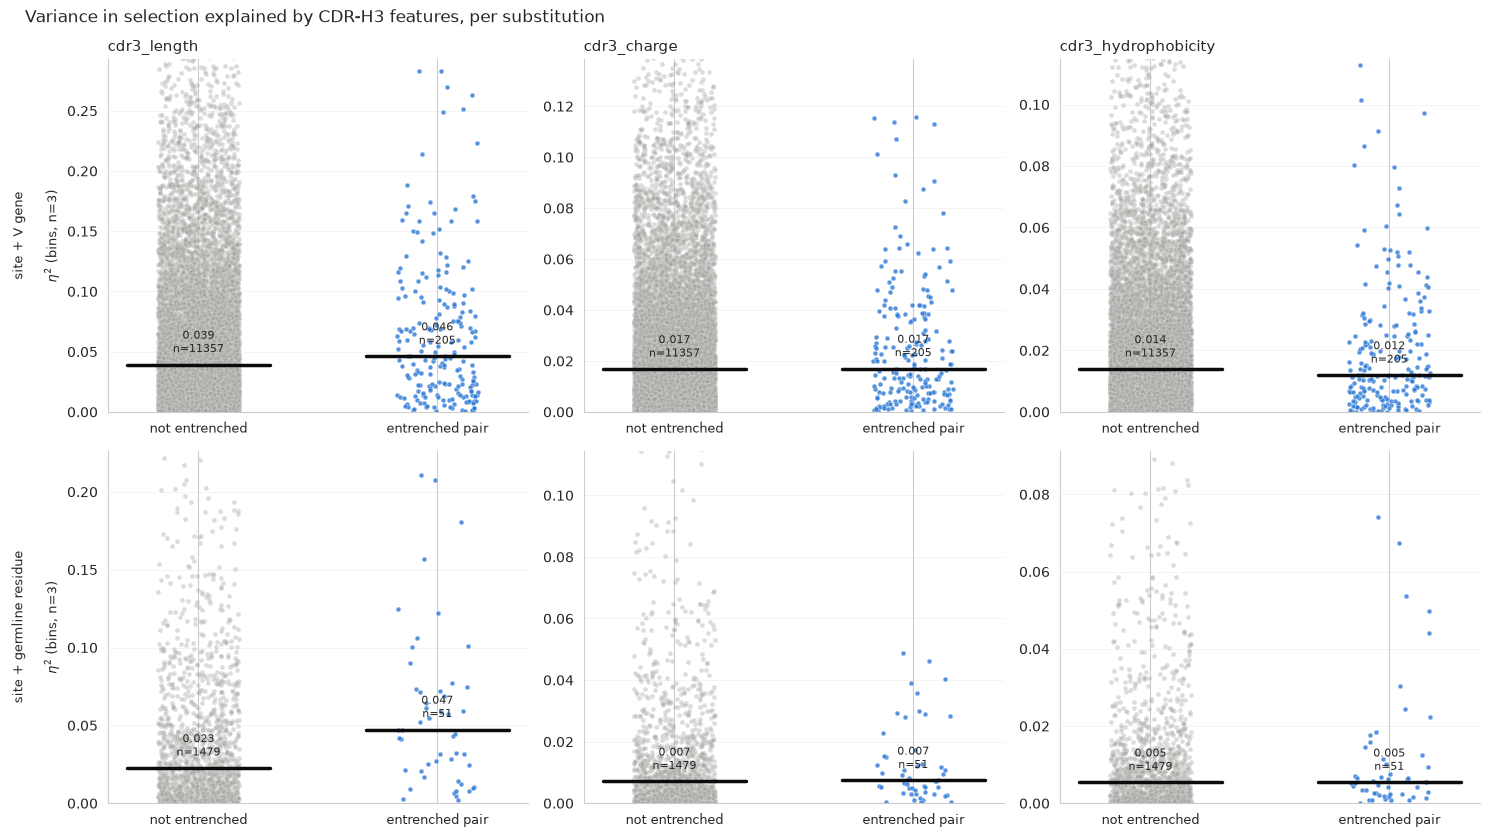

In [8]:
fig, axes = plt.subplots(len(cu.SUBSTITUTION_GROUPINGS), 3, figsize=(15, 8.5))
rng = np.random.default_rng(0)
for row, grouping in enumerate(cu.SUBSTITUTION_GROUPINGS):
    for col, desc in enumerate(cu.CDR3_DESCRIPTORS):
        ax = axes[row, col]
        r = results[(grouping, "bins (n=3)", desc)]
        groups = [(~r.entrenched, GREY, "not entrenched"),
                  (r.entrenched, BLUE, "entrenched pair")]
        for i, (mask, colour, label) in enumerate(groups):
            v = r.loc[mask, "r2"].to_numpy()
            ax.plot(i + rng.uniform(-0.17, 0.17, len(v)), v, "o", ms=3.5, color=colour,
                    mec="white", mew=0.3, alpha=0.35 if i == 0 else 0.8, zorder=2)
            ax.plot([i - 0.3, i + 0.3], [np.median(v)] * 2, "-", color="#0b0b0b", lw=2.5,
                    zorder=4)
            ax.annotate(f"{np.median(v):.3f}\nn={len(v)}", (i, np.median(v)), fontsize=8,
                        xytext=(0, 9), textcoords="offset points", ha="center")
        ax.set_xticks([0, 1])
        ax.set_xticklabels([g[2] for g in groups], fontsize=9)
        ax.set_ylim(0, np.percentile(r.r2, 99))
        ax.grid(alpha=0.25, lw=0.6, axis="y")
        ax.set_axisbelow(True)
        for sp in ("top", "right"):
            ax.spines[sp].set_visible(False)
        if row == 0:
            ax.set_title(desc, fontsize=11, loc="left")
        if col == 0:
            ax.set_ylabel(f"{grouping}\n\n$\\eta^2$ (bins, n={N_BINS})", fontsize=9.5)
fig.suptitle("Variance in selection explained by CDR-H3 features, per substitution",
             fontsize=12.5, x=0.02, ha="left")
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/fig1_entrenched_vs_not.pdf", dpi=300, bbox_inches="tight")
plt.show()

### Figure 2 — per site, against CDR-H3 burial

Each point is a site, summarised as the median across its substitutions. Within-family
entrenched sites are coloured and labelled; between-family entrenched sites are marked
separately.

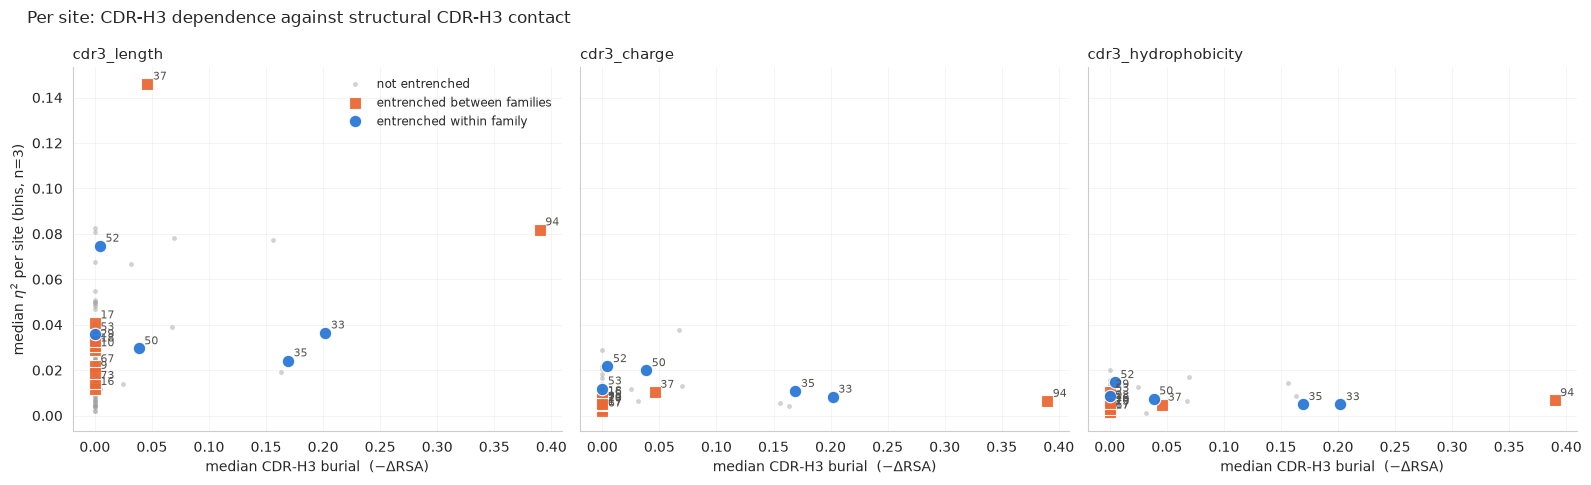

In [9]:
STYLE = {"within-family": (BLUE, "o", 9.0, "entrenched within family"),
         "between-family": (ORANGE, "s", 8.0, "entrenched between families"),
         "not entrenched": (GREY, ".", 7.0, "not entrenched")}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.9), sharey=True)
for ax, desc in zip(axes, cu.CDR3_DESCRIPTORS):
    r = results[(PRIMARY, "bins (n=3)", desc)]
    per_site = r.groupby("site").r2.median().to_frame("r2").join(site_meta)
    for status in ["not entrenched", "between-family", "within-family"]:
        g = per_site[per_site.entrenchment == status]
        colour, marker, size, label = STYLE[status]
        ax.plot(g.cdr3_burial, g.r2, marker, color=colour, ms=size, ls="none",
                mec="white", mew=0.8 if marker != "." else 0,
                alpha=0.45 if status == "not entrenched" else 0.95, label=label,
                zorder=1 if status == "not entrenched" else 3)
    for site, row in per_site[per_site.entrenchment != "not entrenched"].iterrows():
        ax.annotate(site, (row.cdr3_burial, row.r2), fontsize=8, color="#52514e",
                    xytext=(4, 3), textcoords="offset points")
    ax.set_xlabel("median CDR-H3 burial  ($-\\Delta$RSA)")
    ax.set_title(desc, fontsize=11, loc="left")
    ax.grid(alpha=0.25, lw=0.6)
    ax.set_axisbelow(True)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
axes[0].set_ylabel(f"median $\\eta^2$ per site (bins, n={N_BINS})")
axes[0].legend(frameon=False, fontsize=8.5, loc="upper right")
fig.suptitle("Per site: CDR-H3 dependence against structural CDR-H3 contact",
             fontsize=12.5, x=0.02, ha="left")
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/fig2_per_site_vs_burial.pdf", dpi=300, bbox_inches="tight")
plt.show()

### Figure 3 — the strongest substitutions, and where the entrenched pairs sit

The ranking behind the enrichment table. If CDR-H3 dependence concentrates at entrenched
pairs, they should appear near the top rather than being spread through the distribution.

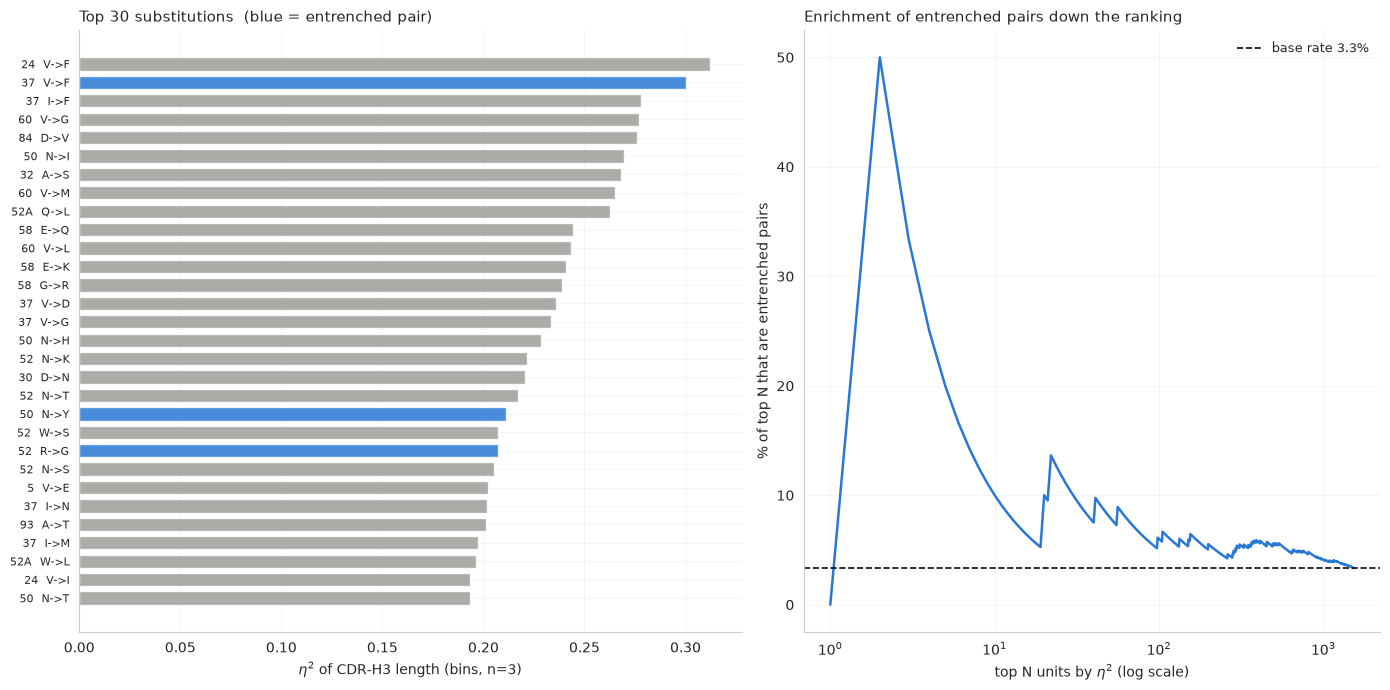

In [10]:
r = results[(PRIMARY, "bins (n=3)", "cdr3_length")].sort_values("r2", ascending=False)
r = r.reset_index(drop=True)
top = r.head(30)

fig, (ax, bx) = plt.subplots(1, 2, figsize=(14, 7),
                             gridspec_kw={"width_ratios": [1.15, 1]})
colours = [BLUE if e else GREY for e in top.entrenched]
ax.barh(range(len(top)), top.r2, color=colours, alpha=0.85, height=0.72)
ax.set_yticks(range(len(top)))
ax.set_yticklabels([f"{s}  {sub}" for s, sub in zip(top.site, top.substitution)],
                   fontsize=8)
ax.invert_yaxis()
ax.set_xlabel(f"$\\eta^2$ of CDR-H3 length (bins, n={N_BINS})")
ax.set_title("Top 30 substitutions  (blue = entrenched pair)", fontsize=11, loc="left")

frac = (r.entrenched.cumsum() / np.arange(1, len(r) + 1))
bx.plot(np.arange(1, len(r) + 1), 100 * frac, "-", color=BLUE, lw=1.8)
bx.axhline(100 * r.entrenched.mean(), color="#0b0b0b", ls="--", lw=1.2,
           label=f"base rate {100 * r.entrenched.mean():.1f}%")
bx.set_xscale("log")
bx.set_xlabel("top N units by $\\eta^2$ (log scale)")
bx.set_ylabel("% of top N that are entrenched pairs")
bx.set_title("Enrichment of entrenched pairs down the ranking", fontsize=11, loc="left")
bx.legend(frameon=False, fontsize=9)
for a in (ax, bx):
    a.grid(alpha=0.25, lw=0.6)
    a.set_axisbelow(True)
    for sp in ("top", "right"):
        a.spines[sp].set_visible(False)
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/fig3_top_substitutions.pdf", dpi=300, bbox_inches="tight")
plt.show()

## 4. What distinguishes the entrenched sites

Entrenchment needs two things: at least two germline residues at the site, and purifying
selection on the substitutions between them. `frac_favored` is the fraction of germline
substitutions with selection factor *above* the neutral rate — the signature of diversifying
rather than purifying selection.

In [11]:
strength = cu.germline_selection_strength(NUMBERING, v_families=tuple(V_FAMILIES)).merge(
    classified[["site_class", "cdr3_burial", "cdr3_contact"]],
    left_on="site", right_index=True)
strength["cdr3_contact"] = strength.cdr3_contact.astype(bool)
strength.to_csv(f"{OUTPUT_DIR}/germline_selection_strength.csv", index=False)
strength.groupby("site_class").agg(
    n=("median_lsf", "size"), median_lsf=("median_lsf", "median"),
    frac_favored=("frac_favored", "median")).round(3)

,n,median_lsf,frac_favored
site_class,,,
"between-family, CDR-H3 contact",3,-0.866,0.250
"between-family, no contact",2,0.288,0.667
"not entrenched, CDR-H3 contact",4,-0.059,0.450
"not entrenched, no contact",24,0.082,0.500
"within-family, CDR-H3 contact",8,-0.969,0.108
"within-family, no contact",2,-0.172,0.469


## 5. Summary

In [12]:
print("Entrenched pairs vs the rest, CDR-H3 length:")
print(contrast[contrast.descriptor == "cdr3_length"][
    ["grouping", "form", "n_units", "n_entrenched", "entrenched", "not_entrenched",
     "fold", "p"]].to_string(index=False))
print()
print("Other descriptors (primary grouping, binned):")
print(contrast[(contrast.grouping == PRIMARY) & (contrast.form == "bins (n=3)")][
    ["descriptor", "entrenched", "not_entrenched", "fold", "p"]].to_string(index=False))
print()
print("Enrichment among the strongest units:")
print(enrichment.to_string(index=False))

Entrenched pairs vs the rest, CDR-H3 length:
               grouping       form  n_units  n_entrenched  entrenched  not_entrenched   fold      p
          site + V gene bins (n=3)    11562           205      0.0463          0.0393 1.1766 0.3377
          site + V gene     linear    11562           205      0.0353          0.0264 1.3344 0.2048
site + germline residue bins (n=3)     1530            51      0.0473          0.0227 2.0890 0.0008
site + germline residue     linear     1530            51      0.0446          0.0186 2.4011 0.0020

Other descriptors (primary grouping, binned):
         descriptor  entrenched  not_entrenched   fold      p
        cdr3_length      0.0473          0.0227 2.0890 0.0008
        cdr3_charge      0.0074          0.0071 1.0454 0.1860
cdr3_hydrophobicity      0.0054          0.0054 0.9986 0.1027

Enrichment among the strongest units:
               grouping  top_n  n_entrenched  pct_entrenched  base_rate_pct  enrichment
          site + V gene     20   

The model-free replication — observed substitution counts with a Poisson exposure offset,
using no DASM — is left out of this notebook for now. It is the slowest section to run and
it was written against the site-level readout, so it would need rebuilding at the
substitution level to be comparable. `cu.fit_cdr3_rate_slope` and
`cu.observed_substitution_counts` are still available for that.

Note that several specifications have been examined — two groupings, two functional forms,
three descriptors — so the claim to make is what holds across them rather than the smallest
p-value among them.